# Titanic Survival Prediction
Predicting passenger survival using classic ML models with Scikit-learn.

**Workflow:** Load -> EDA -> Preprocess -> Train -> Evaluate -> Predict

## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## 2. Load Data

In [7]:
from pathlib import Path

# Try current folder first, then fallback to 01_titanic/ after restructuring
csv_candidates = [Path("titanic.csv"), Path("01_titanic") / "titanic.csv"]
csv_path = next((p for p in csv_candidates if p.exists()), None)

if csv_path is None:
    raise FileNotFoundError("titanic.csv not found in current folder or 01_titanic/")

df = pd.read_csv(csv_path)
print("Loaded:", csv_path)
print("Shape:", df.shape)
df.head()

Loaded: 01_titanic\titanic.csv
Shape: (418, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 3. Exploratory Data Analysis (EDA)

In [8]:
print(df.info())
print("\nMissing values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418 entries, 0 to 417
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  418 non-null    int64  
 1   Survived     418 non-null    int64  
 2   Pclass       418 non-null    int64  
 3   Name         418 non-null    object 
 4   Sex          418 non-null    object 
 5   Age          332 non-null    float64
 6   SibSp        418 non-null    int64  
 7   Parch        418 non-null    int64  
 8   Ticket       418 non-null    object 
 9   Fare         417 non-null    float64
 10  Cabin        91 non-null     object 
 11  Embarked     418 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 39.3+ KB
None

Missing values:
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked    

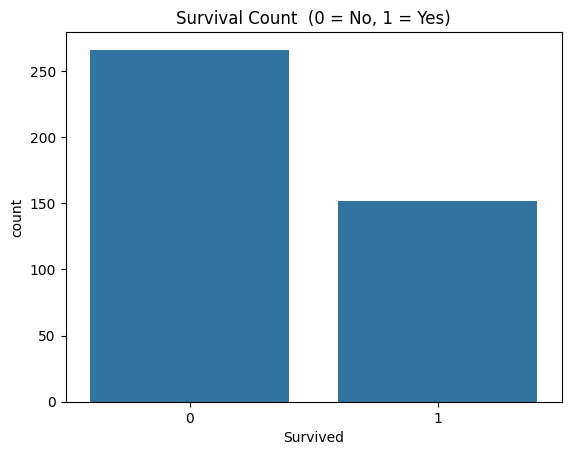

In [9]:
sns.countplot(x="Survived", data=df)
plt.title("Survival Count  (0 = No, 1 = Yes)")
plt.show()

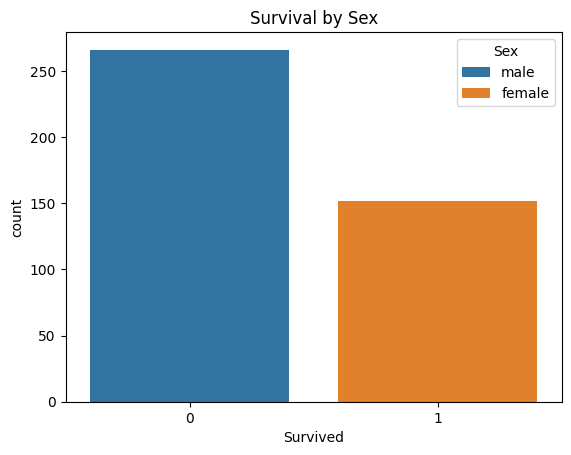

In [10]:
sns.countplot(x="Survived", hue="Sex", data=df)
plt.title("Survival by Sex")
plt.show()

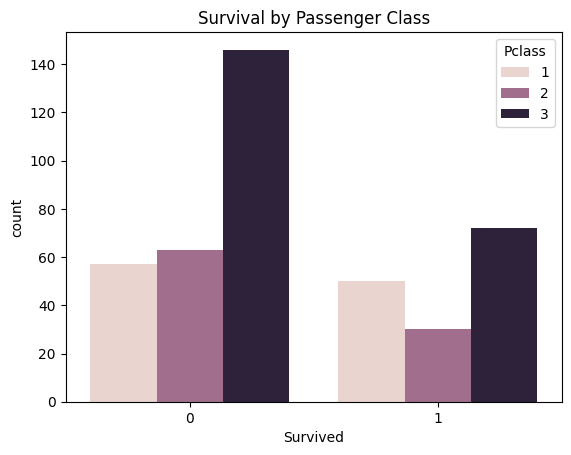

In [11]:
sns.countplot(x="Survived", hue="Pclass", data=df)
plt.title("Survival by Passenger Class")
plt.show()

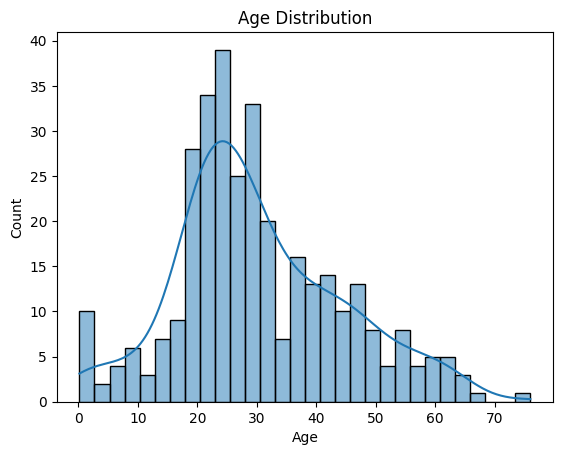

In [12]:
sns.histplot(df["Age"].dropna(), bins=30, kde=True)
plt.title("Age Distribution")
plt.show()

## 4. Preprocess

In [13]:
# Drop irrelevant columns
df.drop(["Name", "Ticket", "Cabin", "PassengerId"], axis=1, inplace=True)

# Encode Sex: female=1, male=0
df["Sex"] = df["Sex"].map({"female": 1, "male": 0})

# Encode Embarked: S=0, C=1, Q=2
df["Embarked"] = df["Embarked"].fillna("S").map({"S": 0, "C": 1, "Q": 2})

# Fill missing Age and Fare with median
df["Age"].fillna(df["Age"].median(), inplace=True)
df["Fare"].fillna(df["Fare"].median(), inplace=True)

print("Missing values remaining:", df.isnull().sum().sum())
df.head()

Missing values remaining: 0


C:\Users\saras\AppData\Local\Temp\ipykernel_25972\645675323.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(), inplace=True)
C:\Users\saras\AppData\Local\Temp\ipykernel_25972\645675323.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For e

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,0,34.5,0,0,7.8292,2
1,1,3,1,47.0,1,0,7.0000,0
2,0,2,0,62.0,0,0,9.6875,2
3,0,3,0,27.0,0,0,8.6625,0
4,1,3,1,22.0,1,1,12.2875,0


## 5. Split Data

In [14]:
X = df.drop("Survived", axis=1)
y = df["Survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Train size:", X_train.shape)
print("Test size: ", X_test.shape)

Train size: (334, 7)
Test size:  (84, 7)


## 6. Train Models

In [15]:
# Model 1: Logistic Regression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
lr_acc = accuracy_score(y_test, lr.predict(X_test))
print(f"Logistic Regression Accuracy: {lr_acc*100:.2f}%")

Logistic Regression Accuracy: 100.00%


In [16]:
# Model 2: Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))
print(f"Random Forest Accuracy:       {rf_acc*100:.2f}%")

Random Forest Accuracy:       100.00%


## 7. Evaluate Best Model

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



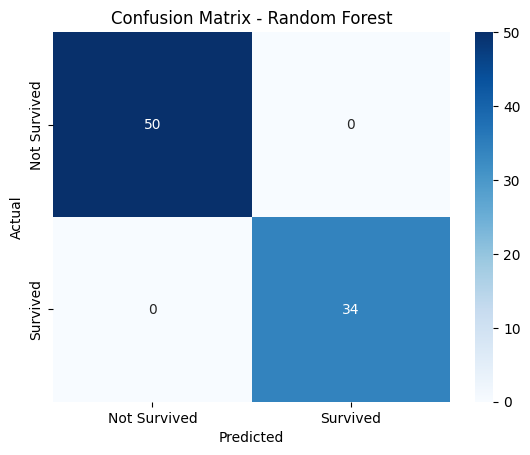

In [17]:
# Using Random Forest as it generally performs better on Titanic
y_pred = rf.predict(X_test)

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Not Survived", "Survived"],
            yticklabels=["Not Survived", "Survived"])
plt.title("Confusion Matrix - Random Forest")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

## 8. Feature Importance

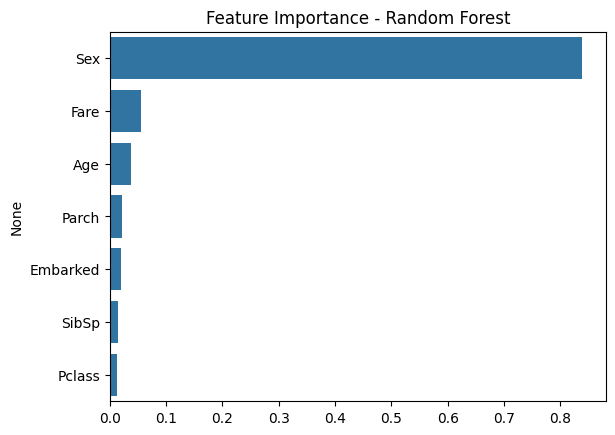

In [18]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

sns.barplot(x=feat_imp.values, y=feat_imp.index)
plt.title("Feature Importance - Random Forest")
plt.show()

## 9. Predict on New Passengers

In [19]:
# [Pclass, Sex, Age, SibSp, Parch, Fare, Embarked]
# Sex: female=1, male=0  |  Embarked: S=0, C=1, Q=2
sample = pd.DataFrame([
    [1, 1, 25.0, 0, 0, 100.0, 1],  # 1st class female, age 25, Port C
    [3, 0, 30.0, 0, 0,   7.25, 0], # 3rd class male,   age 30, Port S
], columns=X.columns)

predictions = rf.predict(sample)
proba       = rf.predict_proba(sample)

for i, (pred, prob) in enumerate(zip(predictions, proba)):
    status = "Survived" if pred == 1 else "Not Survived"
    print(f"Passenger {i+1}: {status}  (Confidence: {max(prob)*100:.1f}%)")

Passenger 1: Survived  (Confidence: 95.0%)
Passenger 2: Not Survived  (Confidence: 98.0%)
